# Zomato Mumbai Data Analysis Project

This CSV dataset contains information pertaining to various Zomato restaurants in Mumbai, like restaurant names, cuisine, ratings, votes, location, etc. This dataset will help you with answering various questions, like which restaurant has the best Continental dishes, or which locality has the best Japanese restaurants, and so on.


## 1. Import Libraries

In [59]:
import pandas as pd
import numpy as np
from data_analysis_utils import Univariate as univ
from data_analysis_utils import Preprocessing as prep
from data_analysis_utils import NormalDistribution as norm
import plotly.express as px


## 2. Import Dataset

In [60]:
raw_data = pd.read_csv('Zomato_Mumbai_Dataset.csv', delimiter='|')
raw_data


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Mumbai,First International Financial Centre-- Bandra ...,https://www.zomato.com/mumbai/hitchki-bandra-k...,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mumbai,Mahim,https://www.zomato.com/mumbai/baba-falooda-mah...,1,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/butterfly-high-b...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/bkc-dive-bandra-...,1,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995
...,...,...,...,...,...,...,...,...,...,...,...,...
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Mumbai,Kandivali West,https://www.zomato.com/mumbai/hari-om-snack-ba...,99,Quick Bites,11am to 230am(Mon-Sun),Good,3.7,64
15077,PitaBurg,400,"Fast Food,Lebanese",Mumbai,Lower Parel,https://www.zomato.com/mumbai/pitaburg-lower-p...,99,none,"11am to 11pm(Mon,Tue,Wed,Thu,Sun),11am to ...",Average,3.4,99
15078,Uncha Otlawala,300,"Desserts,Ice Cream",Mumbai,Kandivali West,https://www.zomato.com/mumbai/uncha-otlawala-1...,99,Dessert Parlor,9am to 1230AM(Mon-Sun),Good,3.5,29
15079,Mandarin Panda,400,"Desserts,Chinese,Thai",Mumbai,Malad West,https://www.zomato.com/mumbai/mandarin-panda-m...,99,none,"12noon to 330pm,7pm to 1am(Mon-Sun)",Good,3.7,121


In [61]:
raw_data.sample(5)


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
106,Mokart,200,"Momos,Chinese,Fast Food",Mumbai,Khar,https://www.zomato.com/mumbai/mokart-khar/info,104,none,"1130am to 330pm,7pm to 1130pm...",NaN,NEW,NEW
860,Dum Biryani,500,"Biryani,Chinese,North Indian,Rolls",Mumbai,Mira Road,https://www.zomato.com/mumbai/dum-biryani-2-mi...,147,none,12noon to 2am(Mon-Sun),Average,3.4,202
7687,Sujata Annex,600,"Chinese,North Indian",Mumbai,Dadar West,https://www.zomato.com/mumbai/sujata-annex-dad...,531,Casual Dining,1130am to 12midnight(Mon-Sun),Good,3.5,104
6299,Hotel Gavran Zatka,400,Maharashtrian,Mumbai,Kamothe,https://www.zomato.com/mumbai/hotel-gavran-zat...,453,Quick Bites,8am to 10pm(Mon-Sun),Not rated,-,-
13452,Hello Biryani,400,"Biryani,Rolls",Mumbai,Kandivali West,https://www.zomato.com/mumbai/hello-biryani-ka...,856,Quick Bites,11am to 11pm(Mon-Sun),Not rated,-,-


## 3. Getting Basic info about Dataset

In [62]:
raw_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15081 entries, 0 to 15080
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   NAME             15081 non-null  object
 1   PRICE            15080 non-null  object
 2   CUSINE_CATEGORY  15079 non-null  object
 3   CITY             15080 non-null  object
 4   REGION           15080 non-null  object
 5   URL              15080 non-null  object
 6   PAGE NO          15080 non-null  object
 7   CUSINE TYPE      15080 non-null  object
 8   TIMING           15015 non-null  object
 9   RATING_TYPE      14070 non-null  object
 10  RATING           15080 non-null  object
 11  VOTES            15080 non-null  object
dtypes: object(12)
memory usage: 1.4+ MB


In [63]:
raw_data.describe()


,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
count,15081,15080,15079,15080,15080,15080,15080,15080,15015,14070,15080,15080
unique,12720,67,3183,2,241,13823,944,23,2551,31,35,1124
top,NAME,400,CUSINE_CATEGORY,Mumbai,REGION,URL,PAGE NO,Quick Bites,11am to 11pm(Mon-Sun),Average,-,-
freq,942,2042,942,14138,942,942,942,5262,1192,5112,2360,2360


## 4. Cleaning Dataset

In [64]:
raw_data[raw_data['PAGE NO']=='PAGE NO'].value_counts()


NAME  PRICE  CUSINE_CATEGORY  CITY  REGION  URL  PAGE NO  CUSINE TYPE  TIMING  RATING_TYPE  RATING  VOTES
NAME  PRICE  CUSINE_CATEGORY  CITY  REGION  URL  PAGE NO  CUSINE TYPE  TIMING  RATING_TYPE  RATING  VOTES    942
Name: count, dtype: int64

In [65]:
# 942 r0ws has only Heading values - to be removed
raw_data = raw_data[raw_data['PAGE NO']!='PAGE NO']

# removing unwanted columns
raw_data=raw_data.drop(columns=['CITY', 'URL', 'PAGE NO'], axis=1)
raw_data


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995
...,...,...,...,...,...,...,...,...,...
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,Quick Bites,11am to 230am(Mon-Sun),Good,3.7,64
15077,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,"11am to 11pm(Mon,Tue,Wed,Thu,Sun),11am to ...",Average,3.4,99
15078,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,Dessert Parlor,9am to 1230AM(Mon-Sun),Good,3.5,29
15079,Mandarin Panda,400,"Desserts,Chinese,Thai",Malad West,none,"12noon to 330pm,7pm to 1am(Mon-Sun)",Good,3.7,121


In [66]:
# remove null columns
raw_data.isnull().sum()


NAME                  0
PRICE                 1
CUSINE_CATEGORY       2
REGION                1
CUSINE TYPE           1
TIMING               66
RATING_TYPE        1011
RATING                1
VOTES                 1
dtype: int64

In [68]:
raw_data.dropna(subset=['PRICE'], inplace=True, ignore_index=True)


In [69]:
# replace other null values to 'NA'
raw_data.fillna('NA', inplace=True)
raw_data.isnull().sum()


NAME               0
PRICE              0
CUSINE_CATEGORY    0
REGION             0
CUSINE TYPE        0
TIMING             0
RATING_TYPE        0
RATING             0
VOTES              0
dtype: int64

### 1. Converting to Numeric Datatypes for numeric columns

#### A. RATING Column

In [70]:
# Check before conversion

raw_data['RATING'].value_counts()


RATING
-          2360
3.5        1094
3.4        1036
3.6         960
NEW         953
3.3         926
3.7         917
3.2         801
3.8         782
3.1         734
3.0         622
3.9         596
2.9         409
4.0         408
2.8         309
4.1         298
4.2         199
2.7         170
4.3         148
4.4          99
2.6          77
Opening      57
4.5          46
2.5          39
4.6          32
2.4          26
4.7          13
2.3          10
2.1           5
4.8           4
2.2           4
4.9           2
1.8           1
2.0           1
Name: count, dtype: int64

In [71]:
# raw_data['RATING'].replace(to_replace=['-', 'NEW', 'Opening'], value=0, inplace=True)
raw_data.replace({'RATING':['-', 'NEW', 'Opening']}, value=0, inplace=True)
raw_data['RATING'].value_counts()


RATING
0      3370
3.5    1094
3.4    1036
3.6     960
3.3     926
3.7     917
3.2     801
3.8     782
3.1     734
3.0     622
3.9     596
2.9     409
4.0     408
2.8     309
4.1     298
4.2     199
2.7     170
4.3     148
4.4      99
2.6      77
4.5      46
2.5      39
4.6      32
2.4      26
4.7      13
2.3      10
2.1       5
4.8       4
2.2       4
4.9       2
1.8       1
2.0       1
Name: count, dtype: int64

#### B. VOTES Column

In [72]:
raw_data['VOTES'].value_counts()


VOTES
-       2360
NEW      953
4        364
5        320
6        288
        ... 
1876       1
2797       1
799        1
3058       1
3529       1
Name: count, Length: 1123, dtype: int64

In [73]:
raw_data.replace({'VOTES':['-', 'NEW', 'Opening']}, value=0, inplace=True)
raw_data['VOTES'].value_counts()


VOTES
0       3370
4        364
5        320
6        288
7        277
        ... 
1510       1
5805       1
3191       1
2092       1
1876       1
Name: count, Length: 1121, dtype: int64

#### C. Converting Price, Votes and Rating Column to Numeric

In [74]:
raw_data['VOTES']=raw_data['VOTES'].astype('int')
raw_data['PRICE']=raw_data['PRICE'].astype('int')
raw_data['RATING']=raw_data['RATING'].astype('float')



In [75]:
raw_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14138 entries, 0 to 14137
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             14138 non-null  object 
 1   PRICE            14138 non-null  int64  
 2   CUSINE_CATEGORY  14138 non-null  object 
 3   REGION           14138 non-null  object 
 4   CUSINE TYPE      14138 non-null  object 
 5   TIMING           14138 non-null  object 
 6   RATING_TYPE      14138 non-null  object 
 7   RATING           14138 non-null  float64
 8   VOTES            14138 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 994.2+ KB


### 2. Working on Timing Column

In [76]:
raw_data['TIMING'].value_counts()


TIMING
11am to 11pm(Mon-Sun)                           1192
11am to 12midnight(Mon-Sun)                      632
12noon to 12midnight(Mon-Sun)                    467
11am to 1130pm(Mon-Sun)                          309
10am to 10pm(Mon-Sun)                            267
                                                ... 
12noon to 4am(Mon-Sat),9am to 4am(Sun)             1
1230pm to 11pm(Mon-Thu),1230pm to 1130pm...        1
830am to 9pm(Mon-Sat),Closed(Sun)                  1
10am to 5pm,7pm to 2am(Mon-Sun)                    1
8am to 11am,12noon to 3pm,730pm to 1130pm...       1
Name: count, Length: 2551, dtype: int64

In [77]:
# splitting the column and store in temp df
temp_df=raw_data['TIMING'].str.split('(', n=1, expand=True)
temp_df


,0,1
0,12noon to 130am,Mon-Sun)
1,2pm to 1am,Mon-Sun)
2,12noon to 1am,Mon-Sun)
3,12noon to 130am,Mon-Sun)
4,1130am to 1am,Mon-Sun)
...,...,...
14133,"8am to 11pm,12midnight to 115am",Mon-Sun)
14134,11am to 230am,Mon-Sun)
14135,11am to 11pm,"Mon,Tue,Wed,Thu,Sun),11am to ..."
14136,9am to 1230AM,Mon-Sun)


In [78]:
temp_df[1] = temp_df[1].str.replace(")", "")
temp_df


,0,1
0,12noon to 130am,Mon-Sun
1,2pm to 1am,Mon-Sun
2,12noon to 1am,Mon-Sun
3,12noon to 130am,Mon-Sun
4,1130am to 1am,Mon-Sun
...,...,...
14133,"8am to 11pm,12midnight to 115am",Mon-Sun
14134,11am to 230am,Mon-Sun
14135,11am to 11pm,"Mon,Tue,Wed,Thu,Sun,11am to ..."
14136,9am to 1230AM,Mon-Sun


In [79]:
raw_data['TIMING'] = temp_df[0]
raw_data['DAYS_OPEN'] = temp_df[1]
raw_data


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14133,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Oshiwara-- Andheri West,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
14134,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun
14135,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,11am to 11pm,Average,3.4,99,"Mon,Tue,Wed,Thu,Sun,11am to ..."
14136,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,Dessert Parlor,9am to 1230AM,Good,3.5,29,Mon-Sun


In [80]:
raw_data.isnull().sum()


NAME                 0
PRICE                0
CUSINE_CATEGORY      0
REGION               0
CUSINE TYPE          0
TIMING               0
RATING_TYPE          0
RATING               0
VOTES                0
DAYS_OPEN          160
dtype: int64

In [81]:
# raw_data['DAYS_OPEN'].fillna('NA', inplace=True)
raw_data.fillna({'DAYS_OPEN':'NA'}, inplace=True)
raw_data.isnull().sum()



NAME               0
PRICE              0
CUSINE_CATEGORY    0
REGION             0
CUSINE TYPE        0
TIMING             0
RATING_TYPE        0
RATING             0
VOTES              0
DAYS_OPEN          0
dtype: int64

### 3. Removing the restaurant records whose Rating or Votes is 0

In [82]:
raw_data = raw_data[(raw_data['RATING']!=0) | (raw_data['VOTES']!=0)].copy()
# raw_data = raw_data


### 4. Working on RATING_TYPE column

In [83]:
raw_data['RATING_TYPE'].value_counts()


RATING_TYPE
Average          5112
Good             4330
Very Good        1137
Excellent          95
Poor               47
Veľmi dobré         6
Skvělá volba        4
Dobrze              4
Bardzo dobrze       3
İyi                 2
Buono               2
Bom                 2
Muito Bom           2
Promedio            2
Dobré               2
Priemer             2
Průměr              2
Ortalama            2
Bueno               2
Excelente           1
Velmi dobré         1
Baik                1
Çok iyi             1
Skvělé              1
Média               1
Sangat Baik         1
Biasa               1
Muy Bueno           1
Media               1
Name: count, dtype: int64

In [84]:
# Translating the texts into proper English text


# create a translation map
translation_map = {
    # Excellent
    'Excelente': 'Excellent',

    # Very Good
    'Veľmi dobré': 'Very Good',
    'Bardzo dobrze': 'Very Good',
    'Muy Bueno': 'Very Good',
    'Velmi dobré': 'Very Good',

    # Good
    'Skvělá volba': 'Good',
    'Dobrze': 'Good',
    'Bueno': 'Good',
    'Buono': 'Good',
    'Dobré': 'Good',
    'Bom': 'Good',
    'Skvělé': 'Good',

    # Average
    'Priemer': 'Average',
    'Média': 'Average',
    'Çok iyi': 'Average',

    # Poor
    'Průměr': 'Poor',
    'Promedio': 'Poor',
    'Ortalama': 'Poor',
    'Muito Bom': 'Poor',
    'İyi': 'Poor',

    # Very Poor
    'Baik': 'Very Poor',
    'Biasa': 'Very Poor',
    'Media': 'Very Poor',
    'Sangat Baik': 'Very Poor'
}

# apply replacements in one go
raw_data['RATING_TYPE'].replace(translation_map, inplace=True)


raw_data['RATING_TYPE'].value_counts()


C:\Users\sulos\AppData\Local\Temp\ipykernel_8668\1001810783.py:44: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





RATING_TYPE
Average      5116
Good         4347
Very Good    1148
Excellent      96
Poor           57
Very Poor       4
Name: count, dtype: int64

### 5. Working on 'REGION' Column

In [85]:
raw_data['REGION'].value_counts()


REGION
Mira Road                            405
Malad West                           309
Chembur                              277
Kharghar                             268
Borivali West                        264
                                    ... 
Little World Mall-- Kharghar           1
Le Sutra Hotel-- Khar                  1
Maxus Mall-- Bhayandar                 1
Orchard Mall-- Goregaon East           1
Hotel Satkar Residency-- Majiwada      1
Name: count, Length: 237, dtype: int64

In [86]:
# Removing the irrelevant text from the Region column
raw_data['REGION'] = raw_data['REGION'].str.replace('[A-Za-z ]+--', '', regex=True)
raw_data['REGION'] = raw_data['REGION'].str.replace(' West| west| East| east','',regex=True)


In [87]:
raw_data['REGION'].value_counts()


REGION
 Thane         712
 Andheri       409
Mira Road      405
Malad          371
Kandivali      361
              ... 
 Ulhasnagar      1
 Chakala         1
 Parel           1
 Dadar           1
 Bhayandar       1
Name: count, Length: 150, dtype: int64

In [88]:
region_map = {
    r'4 Bungalows|7 Andheri|Azad Nagar|Near Andheri Station|Veera Desai Area|Jogeshwari|Oshiwara|Versova': 'Andheri',
    r'Bandra Kurla Complex': 'Bandra',
    r'CBD-Belapur': 'CBD Belapur',
    r'Girgaon Chowpatty|Juhu': 'Chowpatty',
    r'Dadar Shivaji Park': 'Dadar',
    r'Flea Bazaar Café|Kamala Mills Compound': 'Lower Parel',
    r'Runwal Green': 'Mulund',
    r'Mumbai CST Area': 'Mumbai Central',
    r'Kopar Khairane|Seawoods|Turbhe|Ulwe': 'Navi Mumbai',
    r'New Panvel|Old Panvel': 'Panvel',
    r'Kamothe': 'Sion',
    r'Ghodbunder Road|Majiwada': 'Thane'
}

# one-shot replacement
raw_data['REGION'] = raw_data['REGION'].replace(region_map, regex=True)


In [89]:
raw_data['REGION'].value_counts()


REGION
 Thane         715
Andheri        449
 Andheri       411
Mira Road      405
Malad          371
              ... 
 Ulhasnagar      1
 Chakala         1
 Parel           1
 Dadar           1
 Bhayandar       1
Name: count, Length: 126, dtype: int64

### 6. Removing Duplicate records

In [90]:
raw_data[raw_data.duplicated()]


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
3810,Sai Sannidhi Restaurant & Bar,1000,"North Indian,Konkan",Dahisar,Casual Dining,11am to 12midnight,Good,3.7,99,Mon-Sun
3814,Konkan Katta,400,"Seafood,Maharashtrian,Malwani",Mahakali,Quick Bites,"11am to 330pm,630pm to 1130pm",Good,3.5,181,Mon-Sun
3827,Usmaniya Hotel,600,Mughlai,Fort,Casual Dining,1030am to 1130pm,Average,3.2,8,Mon-Sun
3828,Gina's Cakes,450,Bakery,Dombivali,none,11am to 11pm,Good,3.5,49,Mon-Sun
3829,Konkanastha Lunch Home,400,"Seafood,Malwani",Chakala,Casual Dining,"12noon to 3pm,730pm to 1030pm",Good,3.5,44,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
13313,Mezbaan Family Restaurant,350,"Chinese,Mughlai",Mumbra,Dhaba,12noon to 1230AM,Average,2.8,97,Mon-Sun
13317,Jyoti Lunch Home,650,"Chinese,North Indian,Seafood,Mughlai",Mulund,Casual Dining,11am to 1230AM,Good,3.5,49,Mon-Sun
13363,On Toes,900,"Italian,North Indian,Chinese",Malad,Casual Dining,"12noon to 3pm,7pm to 1230AM",Good,3.6,76,Mon-Sun
13839,Frosty Farm,400,"Ice Cream,Desserts,Fast Food",Malad,Dessert Parlor,1pm to 1215AM,Good,3.6,120,Mon-Sun


In [91]:
raw_data = raw_data.drop_duplicates()


### 7. Copying the cleaned data into a new DataFrame

In [92]:
zomato_data = raw_data.copy()
zomato_data


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Chowpatty,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14133,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Andheri,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
14134,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun
14135,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,11am to 11pm,Average,3.4,99,"Mon,Tue,Wed,Thu,Sun,11am to ..."
14136,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor,9am to 1230AM,Good,3.5,29,Mon-Sun


## 5. Performing Exploratory Data Analysis

'NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE', 'TIMING',
       'RATING_TYPE', 'RATING', 'VOTES', 'DAYS_OPEN

### Q1. How many restaurants are in Mumbai for each type of cuisine?

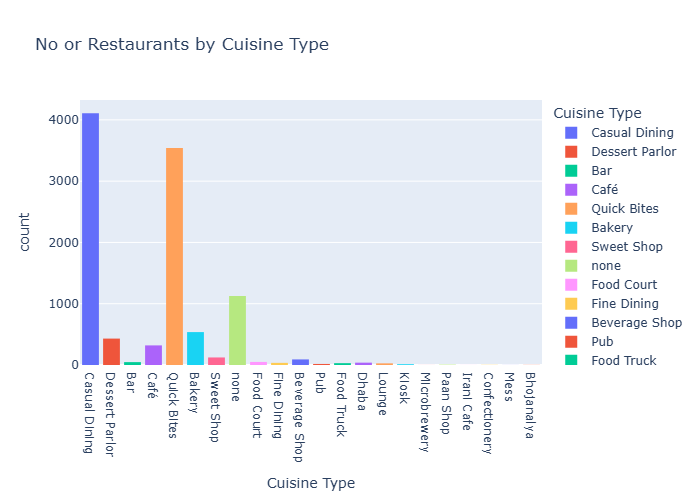

In [93]:
fig = px.histogram(zomato_data, x='CUSINE TYPE', color='CUSINE TYPE',
             title='No or Restaurants by Cuisine Type',
             labels={'CUSINE TYPE':'Cuisine Type'})
fig.show(renderer="png")  


### Q2. What are the percentage of restaurants by Rating Type in Mumbai?

In [94]:
rating_type_df = zomato_data['RATING_TYPE'].value_counts().reset_index()
rating_type_df.rename(columns={'RATING_TYPE': 'Rating Type', 'count':'No of Restaurants'}, inplace=True)
rating_type_df


,Rating Type,No of Restaurants
0,Average,4984
1,Good,4263
2,Very Good,1145
3,Excellent,96
4,Poor,56
5,Very Poor,4


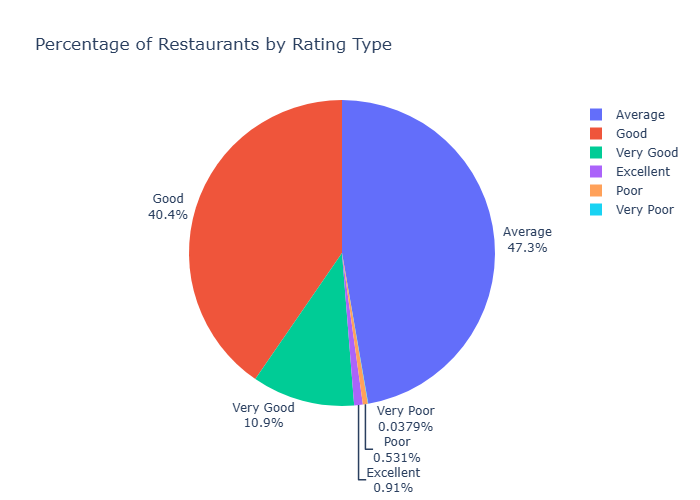

In [95]:
fig = px.pie(rating_type_df, names='Rating Type', values='No of Restaurants', 
             title='Percentage of Restaurants by Rating Type').update_traces(textposition='outside', textinfo='percent+label')
fig.show(renderer="png")  


### Q3. Which are the Top 10 highest rated Seafood Restaurant in Mumbai?

In [96]:
seafood_df = zomato_data[zomato_data['CUSINE_CATEGORY'].str.contains('Seafood')]
seafood_df.sort_values(by='RATING', ascending=False).head(10)


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
6660,Thangabali,1000,"Seafood,South Indian,Mangalorean,Andhra,Kerala",Khar,Bar,"12noon to 4pm,7pm to 3am",Excellent,4.7,564,Mon-Sun
72,Ceremonial Kitchen & Co,1000,"Seafood,Maharashtrian,North Indian,Chinese",Thane,Casual Dining,1130am to 1130pm,Excellent,4.6,350,Mon-Sun
12830,Maharashtra Lunch Home,600,"Maharashtrian,Malwani,Konkan,Seafood",Kharghar,Casual Dining,"11am to 345pm,7pm to 1145pm",Excellent,4.6,209,Mon-Sun
9332,Pi Bar and Kitchen,1600,"Continental,European,Italian,Seafood,Pizza,Des...",Andheri,Bar,"12noon to 6pm,7pm to 12midnight",Excellent,4.5,2068,Mon-Sun
829,Rajmanya- Seafood family restaurant,800,"Maharashtrian,Konkan,Seafood",Vashi,Casual Dining,11am to 11pm,Excellent,4.5,178,Mon-Sun
11656,Quarter Canteen,1100,"North Indian,Seafood,Chinese",Bandra,Casual Dining,"12noon to 330pm,7pm to 1am",Excellent,4.5,573,Mon-Sun
3169,Peco Peco,700,"Chinese,Seafood,Asian",Powai,none,"12noon to 330pm,7pm to 1230AM",Excellent,4.5,497,Mon-Sun
846,The Harbour Bay - SeaFood Kitchen & Bar,2400,"Seafood,Beverages",Bandra,Casual Dining,12noon to 1am,Excellent,4.5,100,Mon-Sun
858,Monis Bar and Restaurant,1000,"North Indian,Chinese,Continental,Seafood,Bever...",Thane,Casual Dining,"1130am to 330pm,6pm to 1130pm",Very Good,4.4,662,Mon-Sun
8335,Hardeep Punjab,1100,"North Indian,Chinese,Mughlai,Seafood",Sion,Casual Dining,11am to 1am,Very Good,4.4,871,Mon-Sun


### Q4. Which is the best Food Truck in Mumbai?

In [97]:
food_truck_df = zomato_data[zomato_data['CUSINE TYPE'].str.contains('Food Truck')]
food_truck_df.sort_values(by='RATING', ascending=False).head(3)


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
246,Dumpling Delights,200,Momos,Matunga,Food Truck,430pm to 930pm,Very Good,4.3,212,Mon-Sun
954,Street Food Co.,250,"Fast Food,Chinese",Virar,Food Truck,6pm to 3am,Very Good,4.1,274,Mon-Sun
7677,Indigo Burger Project- Bar Bank,500,"Burger,Sandwich,Beverages",Chowpatty,Food Truck,12noon to 1am,Good,3.9,39,Mon-Sun


### Q5. Which places have the highest rated restaurant for each Cuisine Type in Mumbai?

In [98]:
# Assuming restaurants having rating above 4.5

highest_rated_df = zomato_data[zomato_data['RATING']>4.5]
highest_rated_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
7,Tanatan,1500,Modern Indian,Chowpatty,Casual Dining,12noon to 130am,Excellent,4.7,1842,Mon-Sun
9,Plum by Bent Chair,1800,Asian,Lower Parel,Casual Dining,12noon to 1am,Excellent,4.7,1876,Mon-Sun
12,Todi Mill Social,1400,"American,North Indian,Chinese,Fast Food,Contin...",Lower Parel,Bar,9am to 1am,Excellent,4.6,5805,"Mon,9am to 130am(Tue-Sun"
47,Spice Republic,1200,"Cafe,Continental,Mediterranean,Mexican,Italian...",Borivali,Café,1130am to 1145pm,Excellent,4.6,1292,Mon-Sun
56,Little West Pizza,600,Pizza,Borivali,Quick Bites,12noon to 12midnight,Excellent,4.6,348,Mon-Sun
62,Downtown China,750,"Chinese,Thai",Andheri,Casual Dining,12noon to 12midnight,Excellent,4.8,162,Mon-Sun
72,Ceremonial Kitchen & Co,1000,"Seafood,Maharashtrian,North Indian,Chinese",Thane,Casual Dining,1130am to 1130pm,Excellent,4.6,350,Mon-Sun
118,Too Much Drama,600,"Fast Food,Roast Chicken,BBQ",Vashi,Casual Dining,5pm to 1130pm,Excellent,4.7,136,"Mon,1pm to 1130pm(Tue-Sun"
140,The Northern Vibe,300,"Momos,Rolls,Fast Food",Powai,Quick Bites,12noon to 1130pm,Excellent,4.8,145,"Mon-Thu,12noon to 12midnight..."


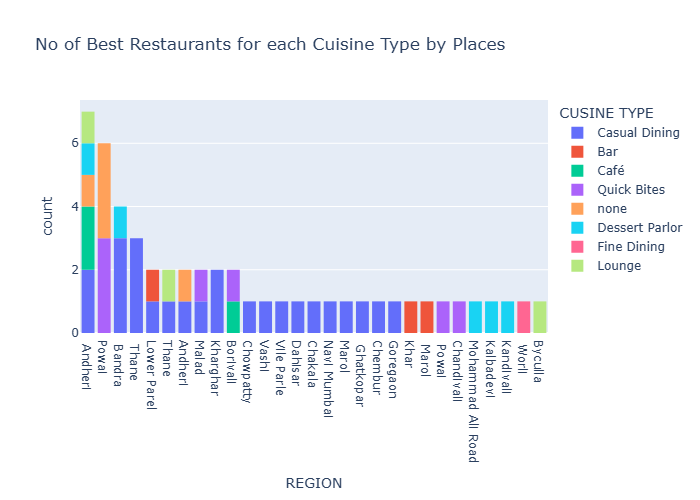

In [99]:
fig = px.histogram(highest_rated_df, x='REGION', color='CUSINE TYPE',
                   title='No of Best Restaurants for each Cuisine Type by Places')
fig.update_xaxes(categoryorder="total descending")
fig.show(renderer="png")  


### Q6. What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Mumbai?

In [100]:
avg_price_highest_rated_df = highest_rated_df.groupby(['REGION','CUSINE TYPE'])['PRICE'].mean().reset_index()
avg_price_highest_rated_df.head(5)


,REGION,CUSINE TYPE,PRICE
0,Andheri,Café,800.0
1,Andheri,Casual Dining,1225.0
2,Andheri,Dessert Parlor,300.0
3,Andheri,Lounge,1700.0
4,Andheri,none,700.0


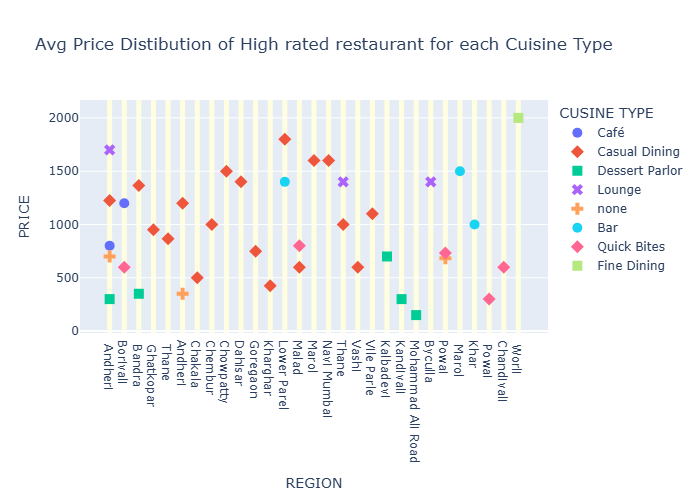

In [101]:
fig = px.scatter(avg_price_highest_rated_df, x="REGION", y="PRICE", color="CUSINE TYPE", symbol="CUSINE TYPE",
                    title=' Avg Price Distibution of High rated restaurant for each Cuisine Type')
fig.update_xaxes(showgrid=True, gridwidth=5, gridcolor='lightyellow')
fig.update_traces(marker_size=10)
fig.show(renderer="png")  


### Q7. Which areas have a large number of Chinese Restaurant Market?

In [102]:
chinese_df = zomato_data[zomato_data['CUSINE_CATEGORY'].str.contains('Chinese')]
chinese_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Chowpatty,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun
5,Flea Bazaar Café,800,"American,Asian,Street Food,North Indian,Luckno...",Lower Parel,Café,12noon to 1am,Very Good,4.2,2042,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14129,Lucknow Zaika,500,"North Indian,Chinese",Kurla,Quick Bites,12noon to 2am,Average,2.6,36,Mon-Sun
14130,Zuha's Kitchen,400,"Chinese,North Indian,Mughlai",Mumbai Central,Quick Bites,"12noon to 4pm,730pm to 430am",Average,3.3,13,Mon-Sun
14133,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Andheri,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
14134,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun


In [103]:
chinese_rest_df = chinese_df.groupby(by='REGION').agg({'NAME' : 'count', 'PRICE' : 'mean'}).rename(columns= {'NAME' : 'COUNT OF RESTAURANTS'}).reset_index()
chinese_rest_df = chinese_rest_df.sort_values('COUNT OF RESTAURANTS', ascending=False).head(25)
chinese_rest_df.head()


,REGION,COUNT OF RESTAURANTS,PRICE
29,Thane,342,590.804094
37,Andheri,229,572.925764
86,Mira Road,220,545.681818
80,Malad,186,598.118280
62,Goregaon,160,540.937500


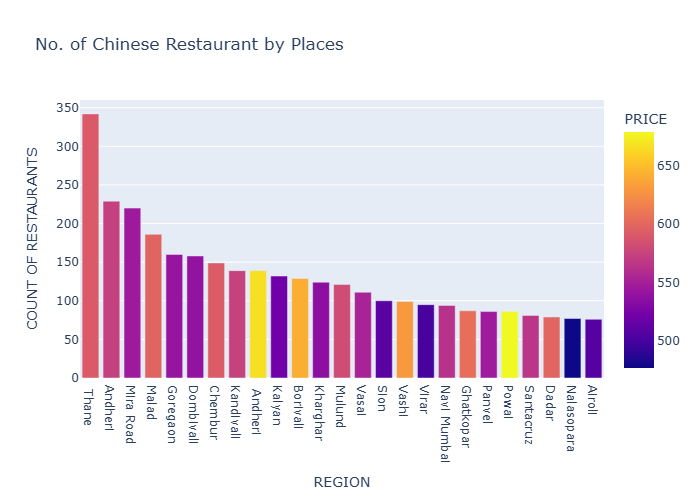

In [104]:
fig = px.bar(chinese_rest_df, x='REGION', y='COUNT OF RESTAURANTS', color='PRICE', title= 'No. of Chinese Restaurant by Places')
fig.show(renderer="png")  


### Q8. Is there a relation between Price and Rating by each Cuisine Type?

In [105]:
price_rating_cusine_df=zomato_data.groupby(['CUSINE TYPE', 'RATING'])['PRICE'].mean().reset_index()
price_rating_cusine_df


,CUSINE TYPE,RATING,PRICE
0,Bakery,2.7,400.000000
1,Bakery,2.8,285.714286
2,Bakery,2.9,328.571429
3,Bakery,3.0,300.000000
4,Bakery,3.1,369.117647
...,...,...,...
278,none,4.3,683.333333
279,none,4.4,555.000000
280,none,4.5,420.000000
281,none,4.6,687.500000


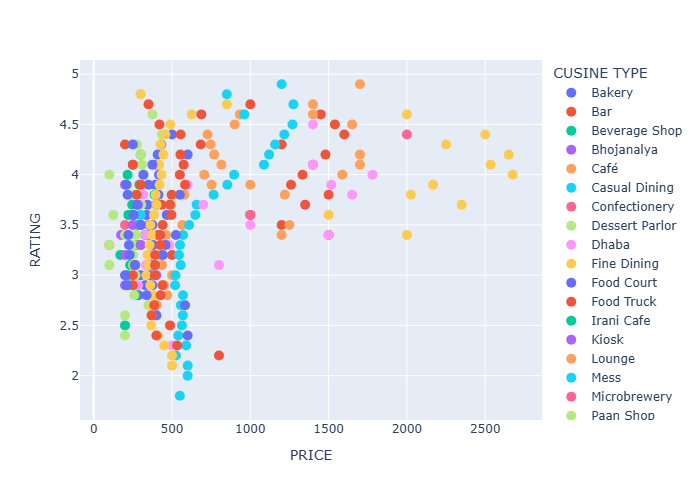

In [106]:
fig=px.scatter(price_rating_cusine_df, y='RATING', x= 'PRICE', color = 'CUSINE TYPE')
fig.update_traces(marker=dict(size=10))
fig.show(renderer="png")  


### Q9. Is there a relation between Region and Price?

In [107]:
reg_price_df = zomato_data.groupby('REGION')['PRICE'].mean().reset_index()
reg_price_df


,REGION,PRICE
0,Andheri,593.292383
1,Bandra,731.843972
2,Bhayandar,150.000000
3,Borivali,1050.000000
4,Byculla,1500.000000
...,...,...
121,Vikhroli,480.434783
122,Vile Parle,464.457831
123,Virar,452.027027
124,Wadala,427.500000


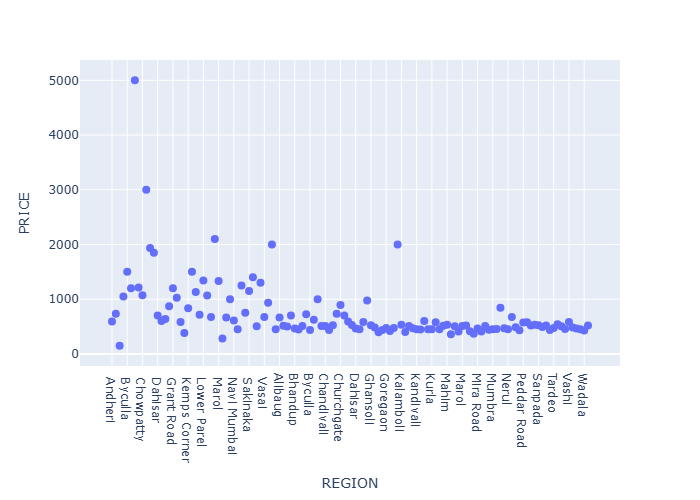

In [108]:
fig=px.scatter(reg_price_df, x='REGION', y='PRICE', height=700)
fig.update_traces(marker_size=8)
fig.show(renderer="png")  


### Q10. Find the list of Affordable Restaurants?

The criteria for Affordable Restaurants would be:-
1) Low Price
2) High Rated

First step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.

Then find restaurants with more than 4.5 Rating from this list

In [109]:
max_price = zomato_data['PRICE'].max()
one_fourth=int(max_price/4)
one_fourth


1250

In [110]:
affordable_df = zomato_data[zomato_data['PRICE'] <= one_fourth]
affordable_df=affordable_df.sort_values(by='PRICE').reset_index(drop=True)
affordable_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Sanjog Wine N Dine,5,"North Indian,Chinese",Thane,Casual Dining,11am to 12midnight,Good,3.5,36,Mon-Sun
1,Jab We Eat,50,"South Indian,North Indian,Maharashtrian,Fast Food",Girgaum,none,5am to 10pm,Average,3.3,8,Mon-Sun
2,Ho5 Store,50,Fast Food,Matunga,none,930am to 10pm,Average,3.2,8,Mon-Sun
3,Pandurang Wada Pav And Sandwich Centre,100,Street Food,Goregaon,Quick Bites,7am to 10pm,Good,3.5,25,Mon-Sun
4,Mothers Tiffin,100,Maharashtrian,Airoli,none,"11am to 1pm,6pm to 11pm",Average,3.3,12,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
10186,Oh! Calcutta,1200,"Bengali,Seafood",Tardeo,Casual Dining,"1230pm to 330pm,730pm to 1130pm",Very Good,4.1,569,Mon-Sun
10187,Kumar Lunch Home,1200,"North Indian,Chinese",Chembur,Casual Dining,12noon to 2am,Average,3.4,103,Mon-Sun
10188,Bijoli Grill,1250,Bengali,Powai,Casual Dining,1230pm to 11pm,Good,3.8,813,Mon-Sun
10189,SamBar Pub & Kitchen,1250,"Finger Food,South Indian,North Indian",Khar,Pub,"12midnight to 1am,630pm to 12midnight",Good,3.9,1090,Mon-Sun


In [111]:
rating_high_affortable_df = affordable_df[affordable_df['RATING'] >= 4.5].reset_index(drop=True)
rating_high_affortable_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Cake Centre-The Dessert Maker,150,Desserts,Mohammad Ali Road,Dessert Parlor,11am to 12midnight,Excellent,4.6,105,Mon-Sun
1,Curry And Combos Twist,200,"North Indian,Chinese",Andheri,Quick Bites,930am to 1130pm,Excellent,4.5,39,Mon-Sun
2,Moussestruck,200,Desserts,Andheri,none,10am to 1145pm,Excellent,4.5,364,Mon-Sun
3,Cone Culture,250,European,Kharghar,Casual Dining,Closed,Excellent,4.6,492,"Mon,12noon to 11pm(Tue-Sun"
4,The Northern Vibe,300,"Momos,Rolls,Fast Food",Powai,Quick Bites,12noon to 1130pm,Excellent,4.8,145,"Mon-Thu,12noon to 12midnight..."
...,...,...,...,...,...,...,...,...,...,...
60,Culinary Tales,1200,"Chinese,European,Continental,Salad,Italian,Pizza",Andheri,Casual Dining,8am to 1am,Excellent,4.7,595,Mon-Sun
61,Invento,1200,"Chinese,Fast Food,North Indian,Italian,Mexican",Lower Parel,Casual Dining,"1130am to 4pm,7pm to 12midnight",Excellent,4.5,190,Mon-Sun
62,Wild Dining Restaurant,1200,"North Indian,Continental,Mexican,Chinese",Andheri,Casual Dining,"12midnight to 1am,12noon to 330pm,7pm to ...",Excellent,4.5,1782,NA
63,The Joker Bistro,1200,"North Indian,Chinese,Continental",CBD Belapur,Casual Dining,12noon to 12midnight,Excellent,4.5,490,Mon-Sun


### Q11. Find the list of most Reliable Restaurants?

The criteria for most Reliable Restaurants would be:-
1) Low Price ( less than 1/4th highest Price )
2) High Rated ( higher than 4.5 )
3) Large No. of Votes ( more than mean Votes )

In [112]:
# Low Price (Less than 1/4th Highest Price)
affordable_price = int(zomato_data['PRICE'].max()/4)
reliable_rest_df = zomato_data[zomato_data['PRICE'] <= affordable_price]
reliable_rest_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun
5,Flea Bazaar Café,800,"American,Asian,Street Food,North Indian,Luckno...",Lower Parel,Café,12noon to 1am,Very Good,4.2,2042,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14133,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Andheri,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
14134,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun
14135,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,11am to 11pm,Average,3.4,99,"Mon,Tue,Wed,Thu,Sun,11am to ..."
14136,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor,9am to 1230AM,Good,3.5,29,Mon-Sun


In [113]:
# Highest Rated
reliable_rest_df = reliable_rest_df[reliable_rest_df['RATING'] >= 4.5]
reliable_rest_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
25,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Andheri,Casual Dining,12noon to 1230AM,Excellent,4.5,271,Mon-Sun
45,Queen Margherita's Pizzeria,600,"Pizza,Fast Food",Malad,Quick Bites,12noon to 11pm,Excellent,4.5,107,"Mon-Thu,12noon to 1130pm(Fri-Sun"
47,Spice Republic,1200,"Cafe,Continental,Mediterranean,Mexican,Italian...",Borivali,Café,1130am to 1145pm,Excellent,4.6,1292,Mon-Sun
56,Little West Pizza,600,Pizza,Borivali,Quick Bites,12noon to 12midnight,Excellent,4.6,348,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
13326,Wild Dining Restaurant,1200,"North Indian,Continental,Mexican,Chinese",Andheri,Casual Dining,"12midnight to 1am,12noon to 330pm,7pm to ...",Excellent,4.5,1782,NA
13345,Cone Culture,250,European,Kharghar,Casual Dining,Closed,Excellent,4.6,492,"Mon,12noon to 11pm(Tue-Sun"
14069,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor,11am to 12midnight,Excellent,4.8,184,Mon-Sun
14110,Tick-eat,800,"North Indian,Italian,Chinese,Mexican,Lebanese",Mulund,Casual Dining,"1130am to 330pm,7pm to 1130pm",Excellent,4.5,754,Mon-Sun


In [114]:
# Large no of votes
mean_votes = int(zomato_data['VOTES'].mean())
reliable_rest_df = reliable_rest_df[reliable_rest_df['VOTES'] >= mean_votes].sort_values(by='VOTES', ascending=False).reset_index(drop=True)
reliable_rest_df


,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Joey's Pizza,800,Pizza,Malad,Quick Bites,11am to 12midnight,Excellent,4.6,7350,Mon-Sun
1,Vedge,1000,"Thai,Chinese,North Indian,Mexican,Italian,Asian",Andheri,Casual Dining,1130am to 1130pm,Excellent,4.5,4017,"Mon-Fri,1130am to 1145pm..."
2,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
3,Cafe Monza,1000,"Italian,American,Salad,Mexican",Kharghar,Casual Dining,10am to 11pm,Excellent,4.5,3389,"Mon,8am to 11pm(Tue-Sun"
4,Bombay Salad Co.,900,"Salad,Healthy Food,Juices",Bandra,Casual Dining,12noon to 1030pm,Good,4.5,2755,Mon-Sun
5,Family Tree,800,"Italian,Mexican,North Indian,Chinese,Salad",Thane,Casual Dining,"1130am to 330pm,630pm to 1130pm",Excellent,4.6,1891,"Mon,Tue..."
6,Wild Dining Restaurant,1200,"North Indian,Continental,Mexican,Chinese",Andheri,Casual Dining,"12midnight to 1am,12noon to 330pm,7pm to ...",Excellent,4.5,1782,NA
7,Rajdhani,950,"Gujarati,Rajasthani,North Indian",Ghatkopar,Casual Dining,"12noon to 330pm,7pm to 11pm",Excellent,4.8,1451,Mon-Sun
8,Aquafire Restaurant,1100,"North Indian,Continental,Chinese,Italian",Vile Parle,Casual Dining,"12noon to 3pm,7pm to 1230AM",Excellent,4.6,1376,Mon-Sun
9,Spice Republic,1200,"Cafe,Continental,Mediterranean,Mexican,Italian...",Borivali,Café,1130am to 1145pm,Excellent,4.6,1292,Mon-Sun
